# Jupyter Notebook
# Lec 32: Hierarchical Clustering

<img src="https://docs.scipy.org/doc/scipy/_images/scipy-cluster-hierarchy-dendrogram-1_01.png" alt="Dendrogram" width="600"/>

In [2]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time

I've made us some data, easy case first, where we've got data that I made drawing from three clusters. You can probably look at the picture and figure out what they should be. 

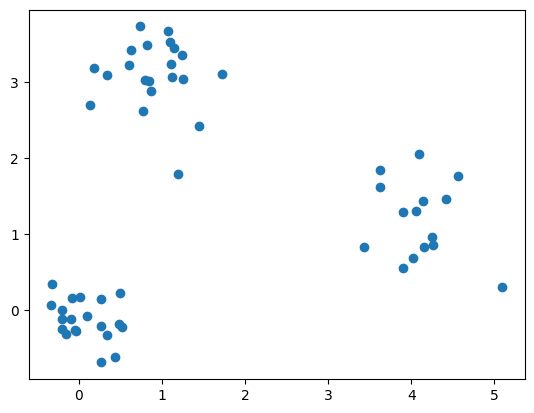

In [3]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/540ccc8f37c0962c8003b5048bca8946/Clustering-ToyData.csv"
X = np.loadtxt(url)
plt.scatter(X[:,0],X[:,1])
plt.show()

But notice that when I look at the order the points are included in the matrix, it's got nothing to do with the order that the points came in the matrix.

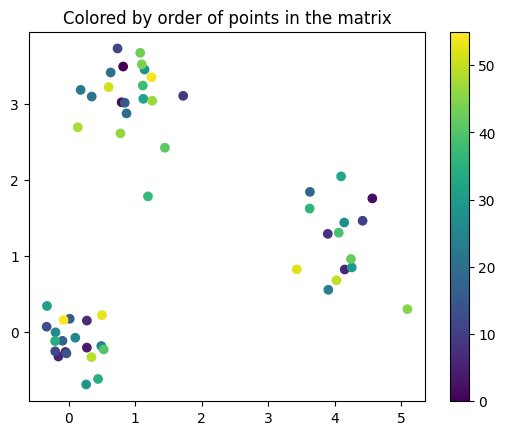

In [4]:
plt.scatter(X[:,0],X[:,1], c = list(range(X.shape[0])))
plt.colorbar()
plt.title('Colored by order of points in the matrix')
plt.show()

The next thing we can do is look at the *distance matrix* of the points, which is a square matrix for which entry `D[i,j]` is the distance between points `i` and `j`. 

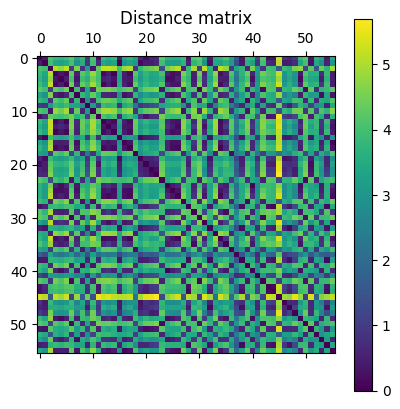

In [5]:
from scipy.spatial import distance_matrix

D = distance_matrix(X,X)

plt.matshow(D)
plt.colorbar()
plt.title('Distance matrix')
plt.show()

There are lots of controls in that function including messing with the choice of distances between the points, but for now we'll leave it at the good ol' fashioned Euclidean distance, 

$$
\| x - y \| = \sqrt{ \sum_k (x_k-y_k)^2 } = \sqrt{(x_1-y_1)^2 + (x_2-y_2)^2}.
$$

Before we go on, here's a trick for figuring out where a particular data point is.

Distance: 3.7599211068694047


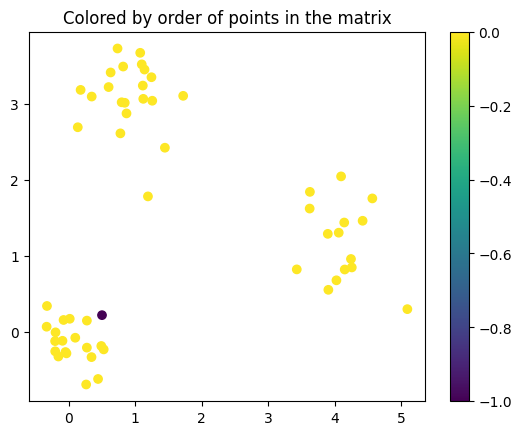

In [6]:
# I want to find point 53

colors = np.zeros(X.shape[0])
colors[53] = -1 #<--- Make the color of point 53 different from the others

plt.scatter(X[:,0],X[:,1], c = colors)
plt.colorbar()
plt.title('Colored by order of points in the matrix')
print('Distance:', D[18,7])
plt.show()

&#9989; **<font color=red>Answer these:</font>** 
- Where are the 7th and 18th (according to python numbering) points in the scatter plot above? 
- Are they in the same cluster (based on eyeballing it) or different clusters?
- What is the distance between the 7th and 18th points? Use the distance matrix to figure it out 


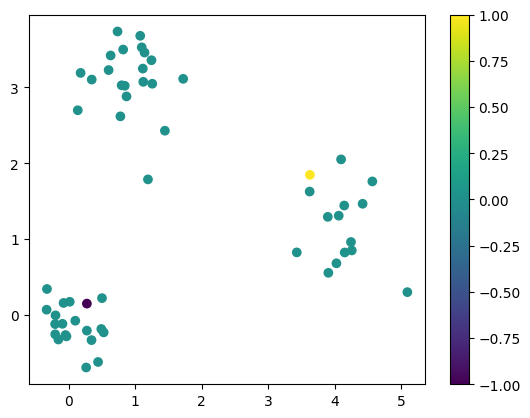

Distance: 3.7599211068694047


In [9]:
# Your code here #

colors = np.zeros(X.shape[0])
colors[7] = -1
colors[18] = 1

plt.scatter(X[:,0], X[:,1], c=colors)
plt.colorbar()
plt.show()
print('Distance:', D[18,7])

# Found by plotting X[7] and X[18] by highlighting. Different clusters.
# Distance between them are about 3.7599211068694047 units away.

I can also play around with looking at the connections like in class, where we connect up points within distance $r$ of each other.  Mess around with the $r$ value below to see what changes. Be careful: large $r$ values wil make for slow drawing.

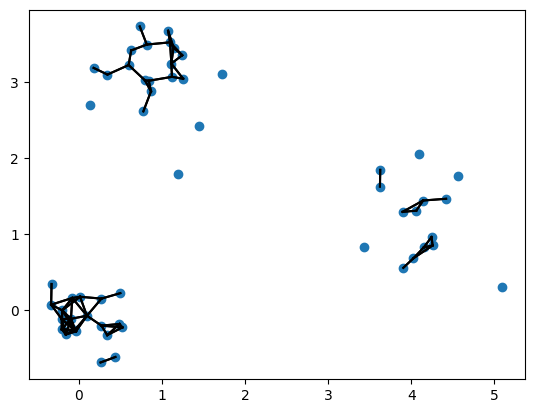

In [10]:
plt.scatter(X[:,0],X[:,1])

r = 0.3

for i in range(X.shape[0]):
    for j in range(X.shape[0]):
        if D[i,j] <= r:
            p = X[(i,j),:]
            plt.plot(p[:,0],p[:,1],c = 'black')

plt.show()

This matrix is very helpful for understanding distances, however, my code in just a moment is going to need the `condensed` distance matrix. It turns out that it has the same information as the above distance matrix, just flattened out. For our purposes, you won't need to fully understand this but the curious can go check out the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html).

In [11]:
from scipy.spatial.distance import pdist

P = pdist(X)
P.shape

(1540,)

And with that, we can get `scipy` to compute our dendrogram for us!

In [12]:
from scipy.cluster import hierarchy

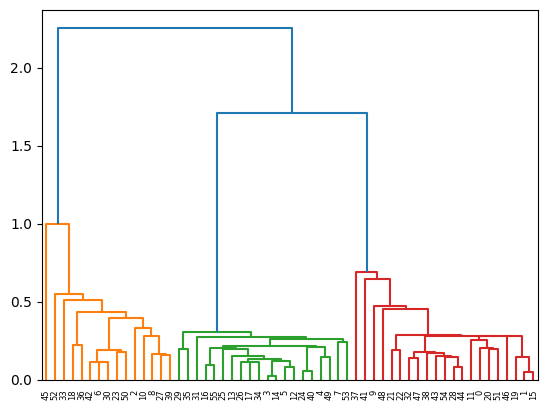

In [14]:
Z = hierarchy.linkage(pdist(X), 'single')

plt.figure()

dn = hierarchy.dendrogram(Z)
plt.show()

First thing to notice, it automatically gives me some color visual guesses for what it thinks the threshold should be for clustering. Hunting around in the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html), it turns out it chooses this threshold based on some information in the linkage diagram......

In [16]:
h = 0.7*max(Z[:,2])  #<---- this equation is what it uses to pick the cutoff
print('Chosen threshold:', h)

Chosen threshold: 1.5807771169466314


...but we can also control the cutoff that it draws the colors

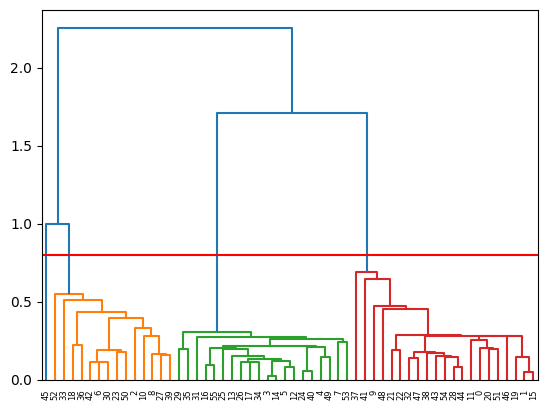

In [17]:
thresh_height = 0.8

dn = hierarchy.dendrogram(Z, color_threshold = thresh_height)
plt.axhline(y = thresh_height, color = 'r', linestyle = '-')
plt.show()

&#9989; **<font color=red>Q:</font>** How many clusters are there if we have a cutoff of 2.0? 


2

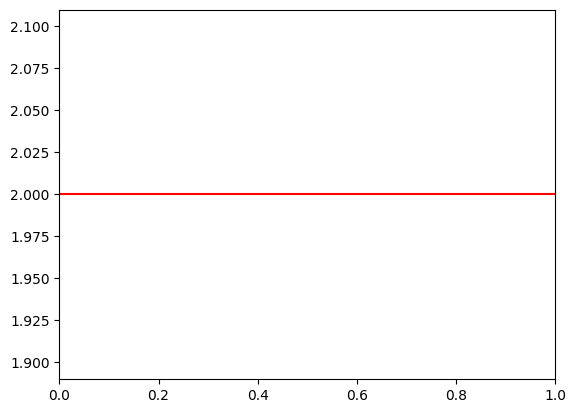

In [25]:
# Your code here #

plt.axhline(y=2.0, color='r', linestyle='-')
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(Z, 2.0, criterion='distance')
len(np.unique(clusters))

# 2 clusters

&#9989; **<font color=red>Q:</font>** (Continue from above) What about for 0.5?

In [26]:
###YOUR CODE HERE##

from scipy.cluster.hierarchy import fcluster
clusters = fcluster(Z, 0.5, criterion='distance')
len(np.unique(clusters))

# 8 clusters

8

Now the magic is that we have the ability to extract the clusters based on the chosen threshold. 

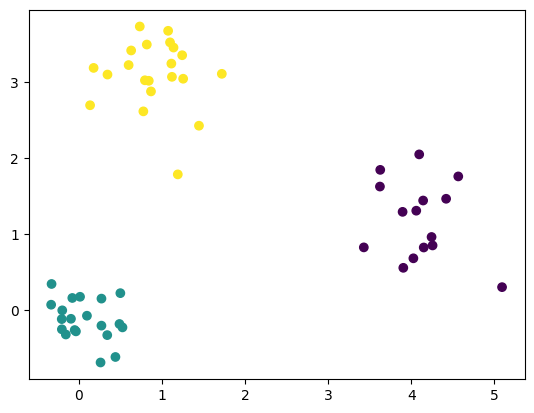

In [27]:
labels = hierarchy.fcluster(Z,h,criterion = 'distance')

plt.scatter(X[:,0],X[:,1],c = labels)
plt.show()


In [28]:
np.unique(labels)

array([1, 2, 3], dtype=int32)

&#9989; **<font color=red>Q:</font>** Where are the clusters associated to a threshold of 2.0? 


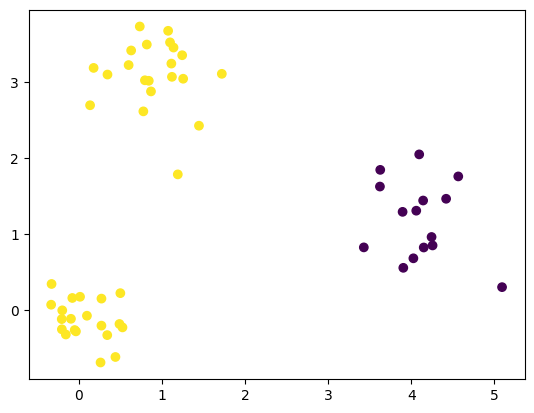

array([1, 2], dtype=int32)

In [32]:
# Your code here #

labels = hierarchy.fcluster(Z, 2.0, criterion='distance')

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

np.unique(labels)

# At a threshold of 2.0, the data forms three clusters.
# Two of the original visually distinct groups are merged into a single cluster,
# while the third group remains separate.
# This occurs because single linkage connects clusters based on the minimum distance between points,
# creating a chain between nearby groups.

&#9989; **<font color=red>Q:</font>** (Continue from above) What about 0.5?

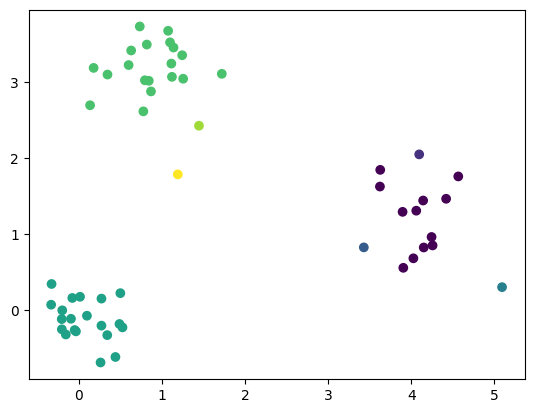

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [36]:
# Your code here #

labels = hierarchy.fcluster(Z, 0.5, criterion='distance')
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
np.unique(labels)

# At a threshold of 0.5, there are many small clusters.
# The original groups are split into several smaller clusters
# because only very close points are merged at this distance.

## A nastier example

I made another data set that's a bit more ambiguous. How many clusters are there? 2? 3? Ok, ok, let's not fight about it. I actually made it using three centers of a normal distribution, but one could argue whether there's two cleanly split clusters, or whether this is related to density and therefore there are 3. 

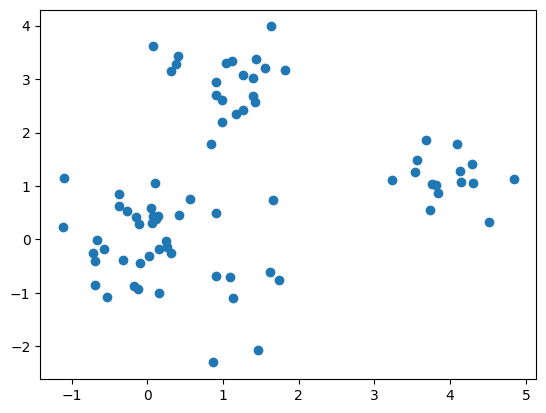

In [37]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/3620eb9976196da8a0f980c4b0435b94/Clustering-ToyData2.csv"
X = np.loadtxt(url)
plt.scatter(X[:,0],X[:,1])
plt.show()

&#9989; **<font color=red>Q:</font>** Draw the single linkage cluster dendogram as above. 
- Is there a reasonable choice of threshold? 
- Using this threshold, how many clusters are there? 
- Draw the cluster assignments on the points using some choice of threshold, reasonable or not. 


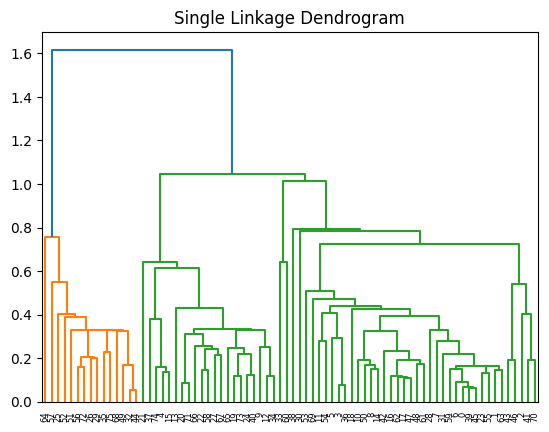

1.1327222206549683


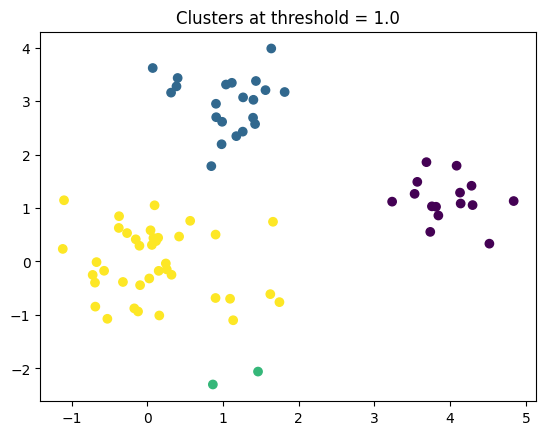

In [41]:
# Your code here #
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy

Z = hierarchy.linkage(pdist(X), 'single')

plt.figure()
hierarchy.dendrogram(Z)
plt.title("Single Linkage Dendrogram")
plt.show()
thresh = 1.0   # try a few values!
h = 0.7 * max(Z[:,2])
print(h)
from scipy.cluster.hierarchy import fcluster

labels = fcluster(Z, thresh, criterion='distance')
len(np.unique(labels))
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title(f"Clusters at threshold = {thresh}")
plt.show()

# The dendrogram does not show a clear gap indicating a natural threshold, so there is no obvious choice for clustering.
# Depending on the threshold selected, the data can be split into 2 or 3 clusters, but neither choice is clearly better.
# This highlights a limitation of single linkage clustering on ambiguous or overlapping data.

Now, we can mess with the choice of linkage to see how this changes the clustering assignment. 



&#9989; **<font color=red>Q:</font>** Modify your linkage to use `complete` instead of `single` and draw the resulting dendrogram.
- Is there a reasonable choice of threshold? 
- Using this threshold, how many clusters are there? 
- Draw the cluster assignments on the points using some choice of threshold, reasonable or not. 


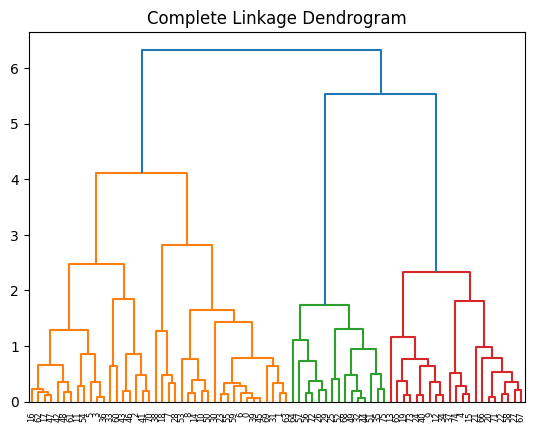

4.432582038316224


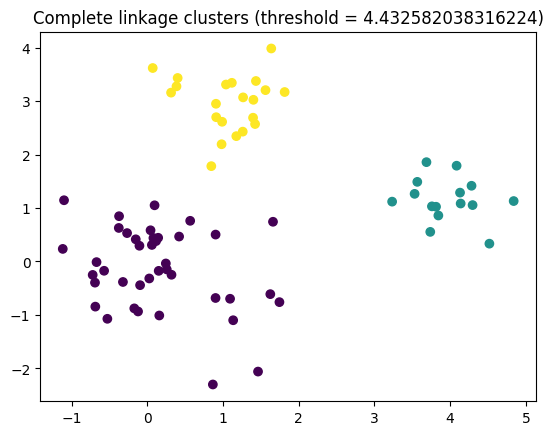

In [44]:
# Your code here #

from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy

Z_complete = hierarchy.linkage(pdist(X), 'complete')

plt.figure()
hierarchy.dendrogram(Z_complete)
plt.title("Complete Linkage Dendrogram")
plt.show()
h = 0.7 * max(Z_complete[:,2])
print(h)
from scipy.cluster.hierarchy import fcluster

labels = fcluster(Z_complete, h, criterion='distance')
len(np.unique(labels))
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title(f"Complete linkage clusters (threshold = {h})")
plt.show()

# Yes. The dendrogram shows a clearer separation with a noticeable vertical gap, making it easier to choose a threshold.
# Using this threshold, there are 3 clusters.
# The scatter plot shows three well-separated groups, matching the expected structure of the data.



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.